# Nutritional Outlier Analysis (Strict Schema, PySpark)

This notebook detects foods with extreme values for key nutrients (e.g., highest sodium, protein, sugar per kcal) and provides recommendations for special dietary needs (iron/vitamin/protein deficiency, etc). Results are visualized and saved to output/NutritionalOutlierAnalysis.

In [36]:
# Imports and Spark session
from pyspark.sql import SparkSession, functions as F
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

spark = SparkSession.builder.appName("NutritionalOutlierAnalysis").getOrCreate()
print("Spark version:", spark.version)

Spark version: 4.0.1


In [37]:
# Configuration
input_path = "output/nutritional_profiles"
fallback_file = "output/nutritional_profiles/part-00000-d5d8abf9-0202-406e-af46-ff13446ce22f-c000.snappy.parquet"
output_dir = "output/NutritionalOutlierAnalysis"
os.makedirs(output_dir, exist_ok=True)

# Strict schema mapping (edit as needed for your dataset)
schema_columns = {
    'id': 'fdc_id',
    'name': 'food_description',
    'category': 'food_type',
    'energy': 'energy',
    'protein': 'protein',
    'carb': 'carbs',
    'fat': 'total_fat',
    'fiber': 'fiber',
    'sugar': 'sugars',
    'saturated_fat': 'saturated_fat',
    'cholesterol': 'cholesterol',
    'sodium': 'sodium',
    'calcium': 'calcium',
    'iron': 'iron',
    'potassium': 'potassium',
    'vitamin_c': 'vitamin_c',
    'vitamin_a': 'vitamin_a',
    'vitamin_b12': 'vitamin_b12',
}

nutrient_cols = [
    'energy', 'protein', 'carb', 'fat', 'fiber', 'sugar', 'saturated_fat',
    'cholesterol', 'sodium', 'calcium', 'iron', 'potassium', 'vitamin_c', 'vitamin_a', 'vitamin_b12'
]

In [38]:
# Data loading with strict schema
from pyspark.sql.types import DoubleType

# Try to load the main Parquet file, fallback if not found
try:
    df = spark.read.parquet(input_path)
except Exception:
    df = spark.read.parquet(fallback_file)

# Rename columns to strict schema
for std_col, orig_col in schema_columns.items():
    if orig_col in df.columns:
        df = df.withColumnRenamed(orig_col, std_col)

# Select only relevant columns
selected_cols = ['id', 'name', 'category'] + nutrient_cols
df = df.select(*[c for c in selected_cols if c in df.columns])

# Convert all nutrient columns to DoubleType
for col in nutrient_cols:
    if col in df.columns:
        df = df.withColumn(col, df[col].cast(DoubleType()))

df.cache()
df.show(5)

+-------+--------------------+------------+------+-------+-----+-----+-----+-----+-------------+-----------+-------+-------+----+---------+---------+---------+-----------+
|     id|                name|    category|energy|protein| carb|  fat|fiber|sugar|saturated_fat|cholesterol| sodium|calcium|iron|potassium|vitamin_c|vitamin_a|vitamin_b12|
+-------+--------------------+------------+------+-------+-----+-----+-----+-----+-------------+-----------+-------+-------+----+---------+---------+---------+-----------+
|1109427|SMOKEY TERIYAKI B...|branded_food| 321.0|  35.71| 25.0| 8.93|  0.0| 25.0|         3.57|       89.0| 1607.0|   71.0|5.14|     NULL|      0.0|     NULL|       NULL|
|1110221|APPLE, BLUEBERRY ...|branded_food|  67.0|    0.0|16.67|  0.0|  1.1|13.33|          0.0|        0.0|    0.0|    0.0| 0.4|    122.0|     13.3|     NULL|       NULL|
|1113353|SOLID MILK & WHIT...|branded_food| 526.0|   5.26|60.53|31.58|  2.6|55.26|        18.42|       13.0|   66.0|  158.0|3.79|     NULL| 

26/01/11 16:48:16 WARN CacheManager: Asked to cache already cached data.


## Outlier Detection for Key Nutrients

This section identifies foods with extreme (high or low) values for each key nutrient. Outliers are detected using the interquartile range (IQR) method for each nutrient. Results are shown for both high and low outliers, and can be used to inform dietary recommendations.

In [39]:
# Outlier detection using IQR for each nutrient
from pyspark.sql import functions as F

def get_outliers(df, col):
    # Calculate Q1 and Q3
    quantiles = df.approxQuantile(col, [0.25, 0.75], 0.01)
    if len(quantiles) < 2:
        return None, None, None, None
    Q1, Q3 = quantiles
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    high_outliers = df.filter(df[col] > upper).select('id', 'name', 'category', col)
    low_outliers = df.filter(df[col] < lower).select('id', 'name', 'category', col)
    return lower, upper, high_outliers, low_outliers

outlier_results = {}
for nutrient in nutrient_cols:
    if nutrient in df.columns:
        lower, upper, high, low = get_outliers(df, nutrient)
        outlier_results[nutrient] = {
            'lower': lower,
            'upper': upper,
            'high': high,
            'low': low
        }
        print(f"Nutrient: {nutrient}")
        print(f"  Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
        print(f"  High outliers: {high.count() if high else 0}, Low outliers: {low.count() if low else 0}")

Nutrient: energy
  Lower bound: -367.00, Upper bound: 849.00
  High outliers: 40, Low outliers: 0
Nutrient: protein
  Lower bound: -13.95, Upper bound: 24.37
  High outliers: 237, Low outliers: 0
Nutrient: carb
  Lower bound: -70.53, Upper bound: 135.34
  High outliers: 8, Low outliers: 0
Nutrient: fat
  Lower bound: -26.79, Upper bound: 44.65
  High outliers: 225, Low outliers: 0
Nutrient: fiber
  Lower bound: -5.40, Upper bound: 9.00
  High outliers: 253, Low outliers: 0
Nutrient: sugar
  Lower bound: -30.73, Upper bound: 54.36
  High outliers: 310, Low outliers: 0
Nutrient: saturated_fat
  Lower bound: -10.47, Upper bound: 17.45
  High outliers: 242, Low outliers: 0
Nutrient: cholesterol
  Lower bound: -34.50, Upper bound: 57.50
  High outliers: 516, Low outliers: 0
Nutrient: sodium
  Lower bound: -732.00, Upper bound: 1324.00
  High outliers: 300, Low outliers: 0
Nutrient: calcium
  Lower bound: -151.50, Upper bound: 252.50
  High outliers: 337, Low outliers: 0
Nutrient: iron
  Low

## Visualize Outliers for Selected Nutrients

This section visualizes the foods with extreme (high/low) values for selected nutrients using bar charts. You can adjust the nutrient of interest to explore different outlier groups.

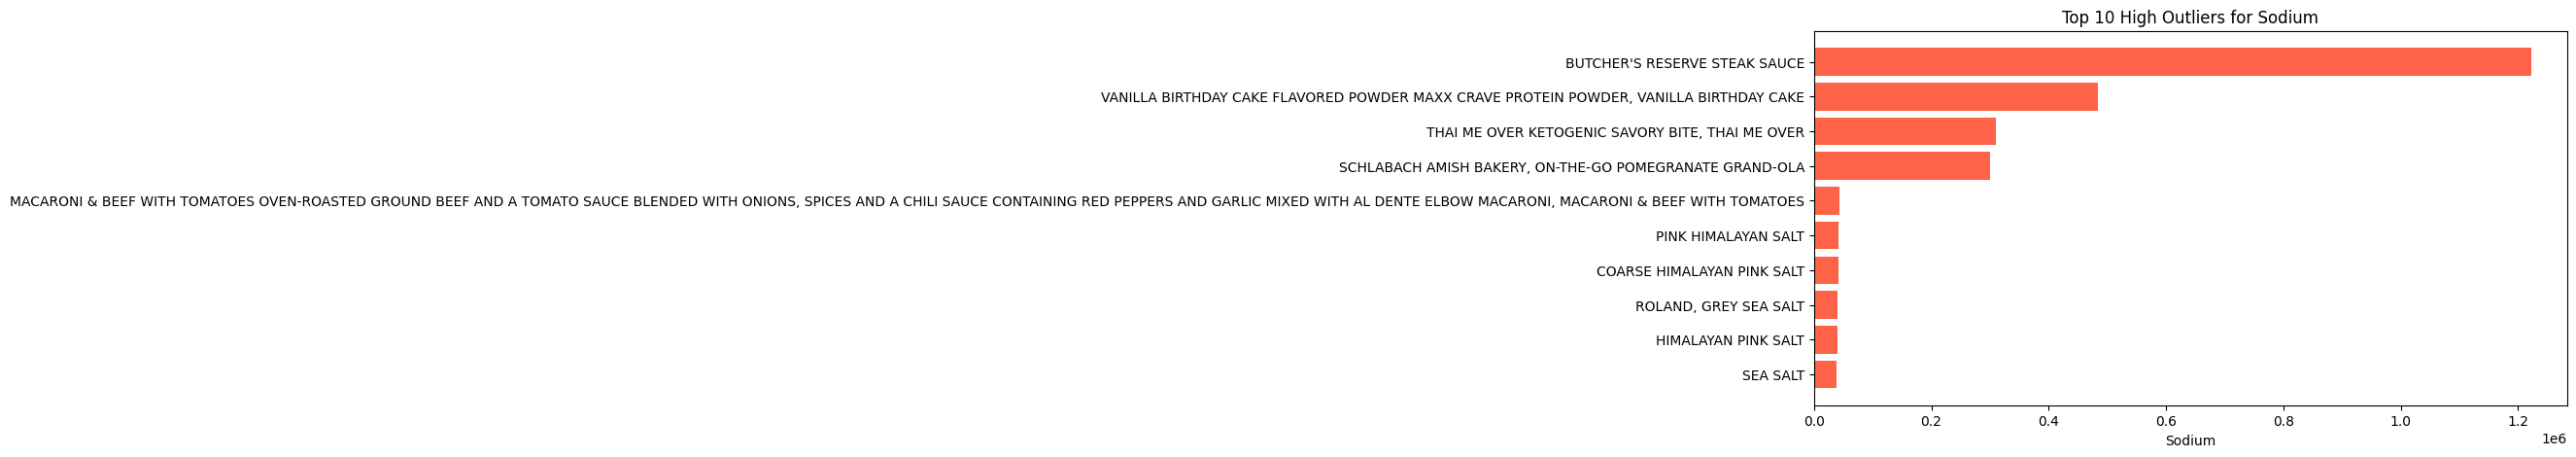

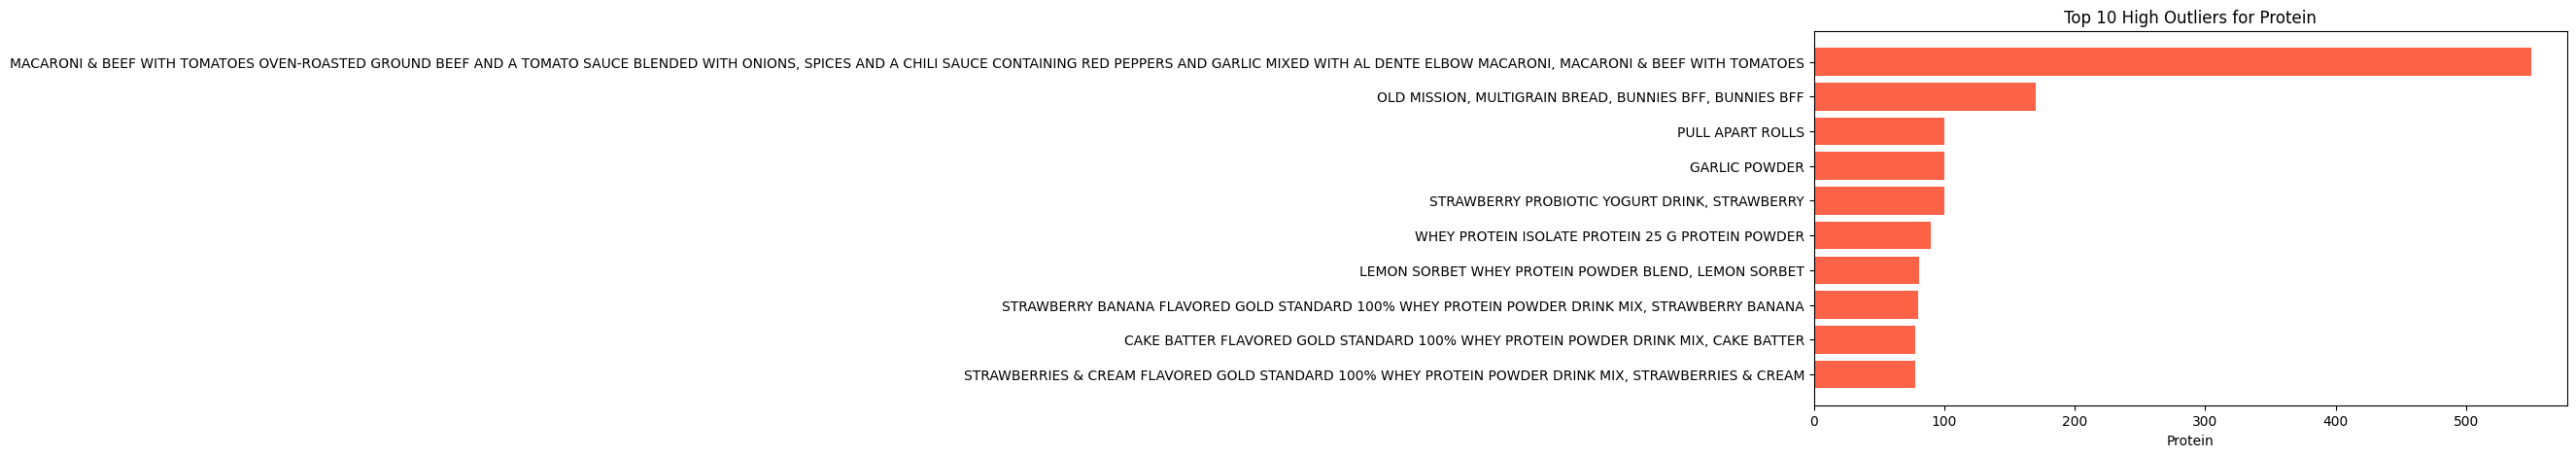

No low outliers for carb.


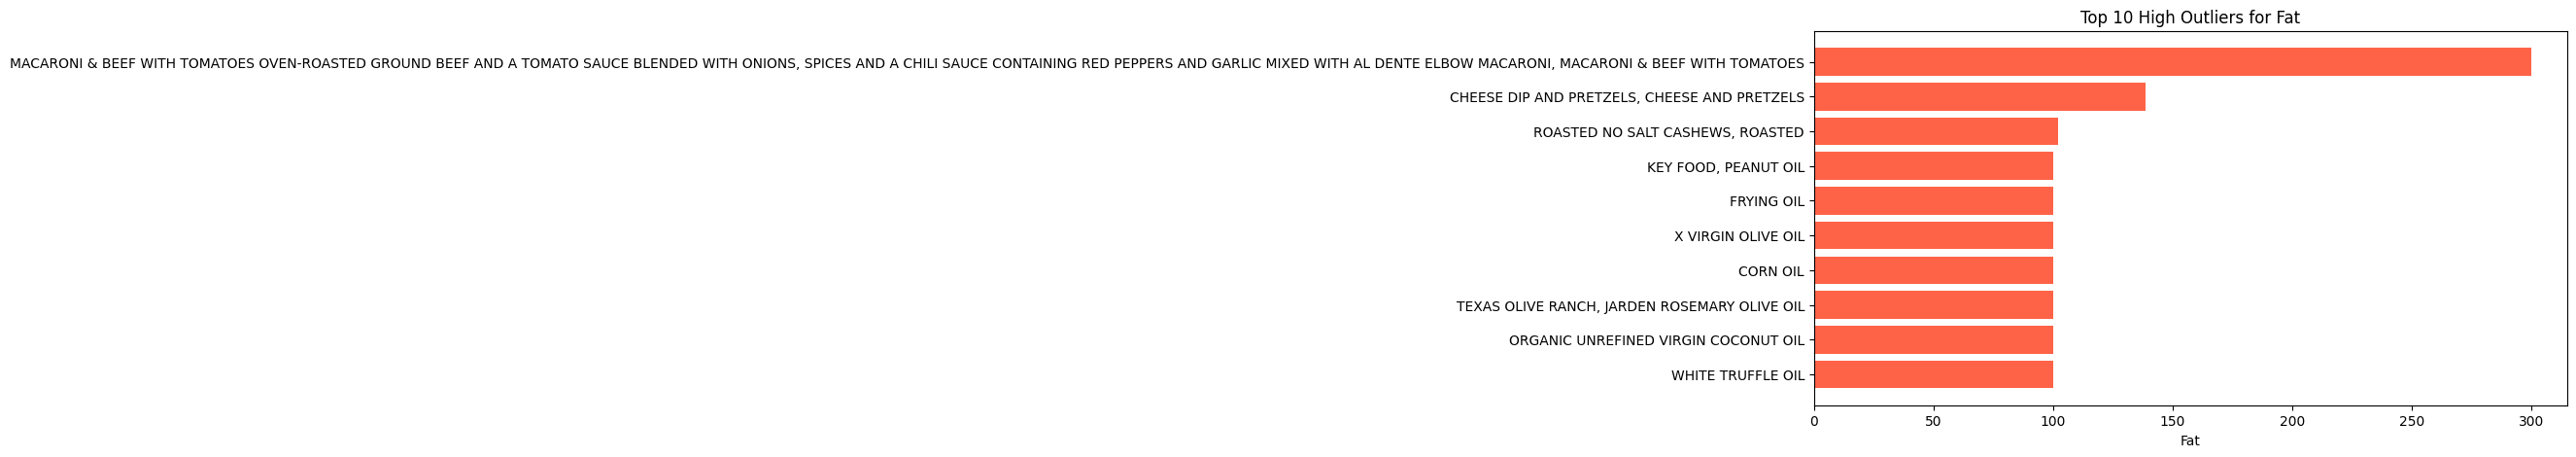

No low outliers for fiber.


In [40]:
# Visualization: Bar chart for high/low outliers of a selected nutrient
import matplotlib.pyplot as plt
import pandas as pd

def plot_outliers(nutrient, outlier_type='high', top_n=10):
    if nutrient not in outlier_results:
        print(f"Nutrient '{nutrient}' not found.")
        return
    sdf = outlier_results[nutrient][outlier_type]
    if sdf is None or sdf.count() == 0:
        print(f"No {outlier_type} outliers for {nutrient}.")
        return
    pdf = sdf.orderBy(F.desc(nutrient) if outlier_type=='high' else F.asc(nutrient)).limit(top_n).toPandas()
    plt.figure(figsize=(10, 5))
    plt.barh(pdf['name'], pdf[nutrient], color='tomato' if outlier_type=='high' else 'skyblue')
    plt.xlabel(nutrient.capitalize())
    plt.title(f"Top {top_n} {'High' if outlier_type=='high' else 'Low'} Outliers for {nutrient.capitalize()}")
    plt.gca().invert_yaxis()
    plt.show()

# Example: Plot high sodium outliers
plot_outliers('sodium', 'high', top_n=10)
# Example: Plot high protein outliers
plot_outliers('protein', 'high', top_n=10)

plot_outliers('carb', 'low', top_n=10)

plot_outliers('fat', 'high', top_n=10)

plot_outliers('fiber', 'low', top_n=10)


## Dietary Recommendations Based on Outlier Analysis

This section provides recommendations for foods suitable for special dietary needs (e.g., high iron for deficiency, low sodium for hypertension) by leveraging the detected outliers. You can adjust the logic to target specific nutrients or dietary goals.

In [ ]:
# Example recommendation logic for special dietary needs
def recommend_foods_for_deficiency(nutrient, top_n=10):
    """Recommend foods high in a given nutrient (for deficiency)."""
    if nutrient not in outlier_results:
        print(f"Nutrient '{nutrient}' not found.")
        return
    sdf = outlier_results[nutrient]['high']
    if sdf is None or sdf.count() == 0:
        print(f"No high outliers for {nutrient}.")
        return
    pdf = sdf.orderBy(F.desc(nutrient)).limit(top_n).toPandas()
    print(f"Top {top_n} foods for {nutrient} deficiency:")
    display(pdf[['name', 'category', nutrient]])
    return pdf

def recommend_foods_for_restriction(nutrient, top_n=10):
    """Recommend foods low in a given nutrient (for restriction)."""
    if nutrient not in outlier_results:
        print(f"Nutrient '{nutrient}' not found.")
        return
    sdf = outlier_results[nutrient]['low']
    if sdf is None or sdf.count() == 0:
        print(f"No low outliers for {nutrient}.")
        return
    pdf = sdf.orderBy(F.asc(nutrient)).limit(top_n).toPandas()
    print(f"Top {top_n} foods for {nutrient} restriction:")
    display(pdf[['name', 'category', nutrient]])
    return pdf

# Example: Recommend foods for iron deficiency
recommend_foods_for_deficiency('iron', top_n=10)
# Example: Recommend foods for sodium restriction
recommend_foods_for_restriction('sodium', top_n=10)

recommend_foods_for_restriction('fat', top_n=10)

recommend_foods_for_restriction('carb', top_n=10)

recommend_foods_for_deficiency('protein', top_n=10)

recommend_foods_for_deficiency('fiber', top_n=10)

recommend_foods_for_deficiency('potassium', top_n=10)

Top 10 foods for iron deficiency:


,name,category,iron
0,"THAI ME OVER KETOGENIC SAVORY BITE, THAI ME OVER",branded_food,3571.43
1,"PLANT-BASED CHICK'N FLAVORED GROUND, CHICK'N",branded_food,615.38
2,MACARONI & BEEF WITH TOMATOES OVEN-ROASTED GRO...,branded_food,65.00
3,Quaker Instant Grits Red Eye Gravy & Country H...,branded_food,43.58
4,ANSIE SEED,branded_food,39.00
5,"WEIS QUALITY, TOASTED RICE CEREAL",branded_food,33.33
6,EARL GREY LIGHTLY CAFFEINED MORINGA ORGANIC SU...,branded_food,33.33
7,"TOASTED RICE BITE SIZE TOASTED RICE CEREAL, TO...",branded_food,33.33
8,ORGANIC DULSE FLAKES,branded_food,33.33
9,INSTANT! MAPLE OATMEAL,branded_food,32.73


No low outliers for sodium.
No low outliers for fat.
No low outliers for carb.
Top 10 foods for protein deficiency:


,name,category,protein
0,MACARONI & BEEF WITH TOMATOES OVEN-ROASTED GRO...,branded_food,550.00
1,"OLD MISSION, MULTIGRAIN BREAD, BUNNIES BFF, BU...",branded_food,170.00
2,PULL APART ROLLS,branded_food,100.00
3,GARLIC POWDER,branded_food,100.00
4,"STRAWBERRY PROBIOTIC YOGURT DRINK, STRAWBERRY",branded_food,100.00
5,WHEY PROTEIN ISOLATE PROTEIN 25 G PROTEIN POWDER,branded_food,89.29
6,"LEMON SORBET WHEY PROTEIN POWDER BLEND, LEMON ...",branded_food,80.65
7,STRAWBERRY BANANA FLAVORED GOLD STANDARD 100% ...,branded_food,80.00
8,CAKE BATTER FLAVORED GOLD STANDARD 100% WHEY P...,branded_food,77.42
9,STRAWBERRIES & CREAM FLAVORED GOLD STANDARD 10...,branded_food,77.42


,id,name,category,protein
0,1829832,MACARONI & BEEF WITH TOMATOES OVEN-ROASTED GRO...,branded_food,550.00
1,1428970,"OLD MISSION, MULTIGRAIN BREAD, BUNNIES BFF, BU...",branded_food,170.00
2,1834880,PULL APART ROLLS,branded_food,100.00
3,2072264,GARLIC POWDER,branded_food,100.00
4,2188024,"STRAWBERRY PROBIOTIC YOGURT DRINK, STRAWBERRY",branded_food,100.00
5,2365677,WHEY PROTEIN ISOLATE PROTEIN 25 G PROTEIN POWDER,branded_food,89.29
6,1960833,"LEMON SORBET WHEY PROTEIN POWDER BLEND, LEMON ...",branded_food,80.65
7,1993199,STRAWBERRY BANANA FLAVORED GOLD STANDARD 100% ...,branded_food,80.00
8,1994764,CAKE BATTER FLAVORED GOLD STANDARD 100% WHEY P...,branded_food,77.42
9,1845303,STRAWBERRIES & CREAM FLAVORED GOLD STANDARD 10...,branded_food,77.42


## Save Outlier and Recommendation Results

This section saves the detected outlier foods and recommendations to CSV and Parquet files in the output/NutritionalOutlierAnalysis directory for further analysis or reporting.

In [42]:
# Save outlier results and recommendations to output directory
for nutrient, res in outlier_results.items():
    for outlier_type in ['high', 'low']:
        sdf = res[outlier_type]
        if sdf is not None and sdf.count() > 0:
            out_path_csv = f"{output_dir}/{nutrient}_{outlier_type}_outliers.csv"
            out_path_parquet = f"{output_dir}/{nutrient}_{outlier_type}_outliers.parquet"
            sdf.write.mode('overwrite').csv(out_path_csv, header=True)
            sdf.write.mode('overwrite').parquet(out_path_parquet)

# Example: Save iron deficiency and sodium restriction recommendations
iron_high = outlier_results['iron']['high']
sodium_low = outlier_results['sodium']['low']
if iron_high is not None and iron_high.count() > 0:
    iron_high.write.mode('overwrite').csv(f"{output_dir}/iron_deficiency_recommendations.csv", header=True)
    iron_high.write.mode('overwrite').parquet(f"{output_dir}/iron_deficiency_recommendations.parquet")
if sodium_low is not None and sodium_low.count() > 0:
    sodium_low.write.mode('overwrite').csv(f"{output_dir}/sodium_restriction_recommendations.csv", header=True)
    sodium_low.write.mode('overwrite').parquet(f"{output_dir}/sodium_restriction_recommendations.parquet")

print(f"All outlier and recommendation results saved to {output_dir}")

All outlier and recommendation results saved to output/NutritionalOutlierAnalysis
